# Lab04：Normal Geometry 決定 Detector

核心問題：當每個 feature 的單點值都在 normal range，什麼 cross-feature structure 仍能揭露異常？

主線是 Mahalanobis、PCA projection／$T^2$、SPE 與 LOF。kNN 只用來建立 LOF 的局部鄰域直覺。

## 1. 從一條時間序列換成同一時刻的一個向量

Lab03 問 temporal pattern；Lab04 固定 temporal pattern，只問同一個五分鐘 timestamp 的 cross-feature geometry。

| Phase | Responsibility |
| --- | --- |
| Phase I estimate | fit seasonal profiles、scaler、covariance、PCA、neighbors |
| Phase I calibration | 將不同 raw scores 對齊相同 false-signal budget |
| Phase II monitoring | 套用 frozen transforms，不重新 fit |

「每欄正常」在本 Lab 指每個 5-minute measurement 都未超過 calibrated pointwise marginal threshold；不宣稱 CUSUM／EWMA 無法利用長期 persistence。

## 2. 七個 features 的意義與彼此關係

$$
\mathbf{x}_t=[\text{in\_bps},\text{out\_bps},\text{in\_pps},\text{out\_pps},
\text{avg\_pkt\_bytes},\text{broadcast\_ratio},\text{multicast\_ratio}]^\top
$$

| Feature | Meaning | Important relationship |
| --- | --- | --- |
| `in_bps`, `out_bps` | directional throughput | in/out balance and shared load |
| `in_pps`, `out_pps` | directional packet rate | coupled to bps through packet size |
| `avg_pkt_bytes` | engineered packet-size summary | $\text{bps}\approx8\times\text{bytes}\times\text{pps}$ |
| `broadcast_ratio`, `multicast_ratio` | L2 composition | absolute L2 rates divided by total pps |

這是 LibreNMS-style counters 工程出的 feature vector，不代表每個真實 port 的全部 counters 都可靠。Derived features 會造成共線，因此 covariance conditioning 必須檢查。

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from IPython.display import display
from sklearn.covariance import EmpiricalCovariance, LedoitWolf
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 20)

example = {
    "in_bps": 80_000_000,
    "out_bps": 40_000_000,
    "in_pps": 12_500,
    "out_pps": 5_000,
    "broadcast_pps": 210,
    "multicast_pps": 350,
}
total_pps = example["in_pps"] + example["out_pps"]
example_result = pd.Series({
    "avg_pkt_bytes": (example["in_bps"] + example["out_bps"]) / (8 * total_pps),
    "broadcast_ratio": example["broadcast_pps"] / total_pps,
    "multicast_ratio": example["multicast_pps"] / total_pps,
})
display(example_result.to_frame("value"))

,value
avg_pkt_bytes,857.142857
broadcast_ratio,0.012000
multicast_ratio,0.020000


In [2]:
def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "data" / "synthetic").exists():
            return candidate
    raise FileNotFoundError("Cannot locate repository root")

ROOT = find_repo_root()
DATA_DIR = ROOT / "data" / "synthetic"
FEATURES = (
    "in_bps", "out_bps", "in_pps", "out_pps",
    "avg_pkt_bytes", "broadcast_ratio", "multicast_ratio",
)
CADENCE_MINUTES = 5
SLOTS_PER_DAY = 288

reference = pd.read_csv(DATA_DIR / "lab04_reference.csv", parse_dates=["timestamp"])
scenarios = pd.read_csv(DATA_DIR / "lab04_multivariate_scenarios.csv", parse_dates=["timestamp"])
events = pd.read_csv(
    DATA_DIR / "lab04_multivariate_events.csv",
    parse_dates=["start_time", "end_time"],
)
estimate = reference.query("split == 'estimate'").copy()
calibration = reference.query("split == 'calibrate'").copy()

assert len(estimate) == 42 * SLOTS_PER_DAY
assert len(calibration) == 14 * SLOTS_PER_DAY
assert set(FEATURES) <= set(reference)
assert "event_label" not in scenarios and "normal_mode" not in scenarios
assert set(events["scenario_id"]) == {"M1", "M2", "M3", "M4"}
print({"estimate_rows": len(estimate), "calibration_rows": len(calibration), "scenario_rows": len(scenarios)})

{'estimate_rows': 12096, 'calibration_rows': 4032, 'scenario_rows': 3456}


## 3. 資料模擬 Overview：先知道正常資料怎麼形成

Simulator 先產生 latent traffic volume、packet size 與 L2 packet rates，再組成同一個 timestamp 的七維向量。Reference 同時包含 ordinary traffic 與不定期 file-transfer batch；兩者都是正常狀態，因此 normal data 不是只有一個中心。

| Phase | 用途 |
| --- | --- |
| Estimate | fit seasonal profile、scaler 與 detector |
| Calibration | 只選 threshold，使方法具有相同 false-onset budget |
| M1–M4 | 套用 frozen model，再用獨立 event table 評估 |

| Scenario | 刻意破壞的 geometry | 主要對照 |
| --- | --- | --- |
| M1 | correlation | Mahalanobis |
| M2 | local density | LOF |
| M3 | off-subspace | PCA SPE |
| M4 | along-subspace extent | PCA $T^2$ |

這張表是實驗地圖，不是演算法排行榜；後面要觀察每個方法依賴的 normal geometry 何時成立、何時失效。

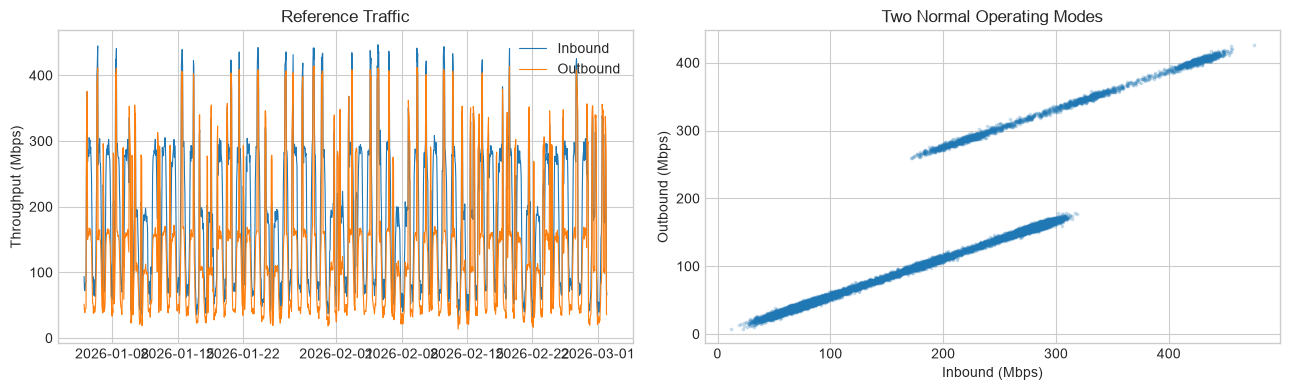

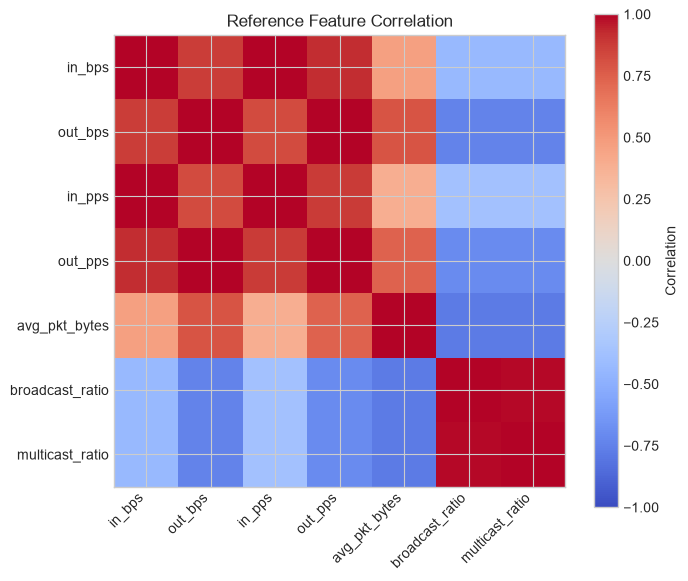

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sample = reference.iloc[::12]
axes[0].plot(sample["timestamp"], sample["in_bps"] / 1e6, linewidth=0.8, label="Inbound")
axes[0].plot(sample["timestamp"], sample["out_bps"] / 1e6, linewidth=0.8, label="Outbound")
axes[0].set(title="Reference Traffic", ylabel="Throughput (Mbps)")
axes[0].legend()
axes[1].scatter(
    reference["in_bps"] / 1e6, reference["out_bps"] / 1e6,
    s=3, alpha=0.18,
)
axes[1].set(title="Two Normal Operating Modes", xlabel="Inbound (Mbps)", ylabel="Outbound (Mbps)")
plt.tight_layout()
plt.show()

corr = reference.loc[:, FEATURES].corr()
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES)), FEATURES)
ax.set_title("Reference Feature Correlation")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

## 4. 沿用 Lab03：先移除 seasonality

$$
\mathbf{x}_t=\widehat{\mathbf{s}}_t+\mathbf{r}_t,
\qquad \mathbf{r}_t=\mathbf{x}_t-\widehat{\mathbf{s}}_t
$$

只用 estimate 依 weekday/weekend 與 288 個 five-minute slots 求平均，再做 `radius=6` circular smoothing。Calibration 與 Phase II 只套用 frozen profile。Lab04 再用 estimate residual fit `StandardScaler`，使 distance-based methods 共用相同表示。

In [4]:
def validate_frame(frame, feature_columns=FEATURES):
    missing = sorted(set(feature_columns) - set(frame.columns))
    if missing:
        raise ValueError(f"Missing features: {missing}")
    if frame["timestamp"].duplicated().any():
        raise ValueError("Duplicate timestamps")
    gaps = frame["timestamp"].sort_values().diff().dropna()
    if len(gaps) and not gaps.eq(pd.Timedelta(minutes=CADENCE_MINUTES)).all():
        raise ValueError("Non-five-minute timestamp gap")
    if not np.isfinite(frame.loc[:, feature_columns].to_numpy()).all():
        raise ValueError("Nonfinite feature value")

def add_time_features(frame):
    result = frame.copy()
    result["day_type"] = np.where(result["timestamp"].dt.dayofweek >= 5, "weekend", "weekday")
    result["slot"] = (result["timestamp"].dt.hour * 60 + result["timestamp"].dt.minute) // CADENCE_MINUTES
    return result

def fit_seasonal_profiles(estimate_frame, feature_columns=FEATURES, radius=6):
    validate_frame(estimate_frame, feature_columns)
    work = add_time_features(estimate_frame)
    profiles = {}
    for day_type in ("weekday", "weekend"):
        raw = (work.loc[work["day_type"].eq(day_type)]
               .groupby("slot")[list(feature_columns)].mean()
               .reindex(range(SLOTS_PER_DAY)).interpolate(limit_direction="both"))
        shifted = [np.roll(raw.to_numpy(), shift, axis=0) for shift in range(-radius, radius + 1)]
        profile = pd.DataFrame(np.mean(np.stack(shifted), axis=0), columns=feature_columns)
        expected_shape = (SLOTS_PER_DAY, len(feature_columns))
        if profile.shape != expected_shape or profile.isna().any().any():
            raise ValueError("Incomplete seasonal profile")
        profiles[day_type] = profile
    return profiles

def apply_seasonal_profiles(frame, profiles, feature_columns=FEATURES):
    work = add_time_features(frame)
    values = np.vstack([
        profiles[day_type].loc[slot, list(feature_columns)].to_numpy()
        for day_type, slot in zip(work["day_type"], work["slot"])
    ])
    return pd.DataFrame(values, index=frame.index, columns=feature_columns)

def seasonal_residuals(frame, profiles, feature_columns=FEATURES):
    return frame.loc[:, feature_columns] - apply_seasonal_profiles(frame, profiles, feature_columns)

def fit_feature_scaler(estimate_residuals):
    zero = estimate_residuals.columns[estimate_residuals.var(ddof=0).eq(0)].tolist()
    if zero:
        raise ValueError(f"Zero-variance features: {zero}")
    return StandardScaler().fit(estimate_residuals)

,estimate_mean,calibration_mean,scaled_std
in_bps,0.0,5.536978e+06,1.0
out_bps,0.0,9.364724e+06,1.0
in_pps,-0.0,8.435564e+02,1.0
out_pps,-0.0,1.076774e+03,1.0
avg_pkt_bytes,-0.0,6.243300e+00,1.0
broadcast_ratio,-0.0,-5.000000e-04,1.0
multicast_ratio,-0.0,-9.000000e-04,1.0


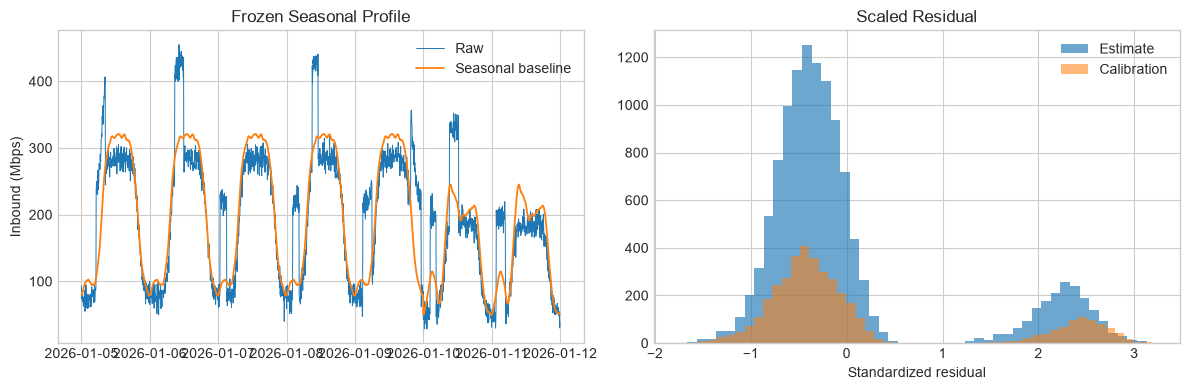

In [5]:
seasonal_profiles = fit_seasonal_profiles(estimate)
estimate_residuals = seasonal_residuals(estimate, seasonal_profiles)
calibration_residuals = seasonal_residuals(calibration, seasonal_profiles)
scaler = fit_feature_scaler(estimate_residuals)
estimate_scaled = scaler.transform(estimate_residuals)
calibration_scaled = scaler.transform(calibration_residuals)

diagnostics = pd.DataFrame({
    "estimate_mean": estimate_residuals.mean(),
    "calibration_mean": calibration_residuals.mean(),
    "scaled_std": pd.DataFrame(estimate_scaled, columns=FEATURES).std(ddof=0),
})
display(diagnostics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
week = estimate.iloc[: 7 * SLOTS_PER_DAY]
baseline = apply_seasonal_profiles(week, seasonal_profiles)
axes[0].plot(week["timestamp"], week["in_bps"] / 1e6, linewidth=0.7, label="Raw")
axes[0].plot(week["timestamp"], baseline["in_bps"] / 1e6, linewidth=1.3, label="Seasonal baseline")
axes[0].set(title="Frozen Seasonal Profile", ylabel="Inbound (Mbps)")
axes[0].legend()
axes[1].hist(estimate_scaled[:, 0], bins=50, alpha=0.65, label="Estimate")
axes[1].hist(calibration_scaled[:, 0], bins=50, alpha=0.55, label="Calibration")
axes[1].set(title="Scaled Residual", xlabel="Standardized residual")
axes[1].legend()
plt.tight_layout(); plt.show()

{'query_x_within_3sigma': np.True_, 'query_y_within_3sigma': np.True_}


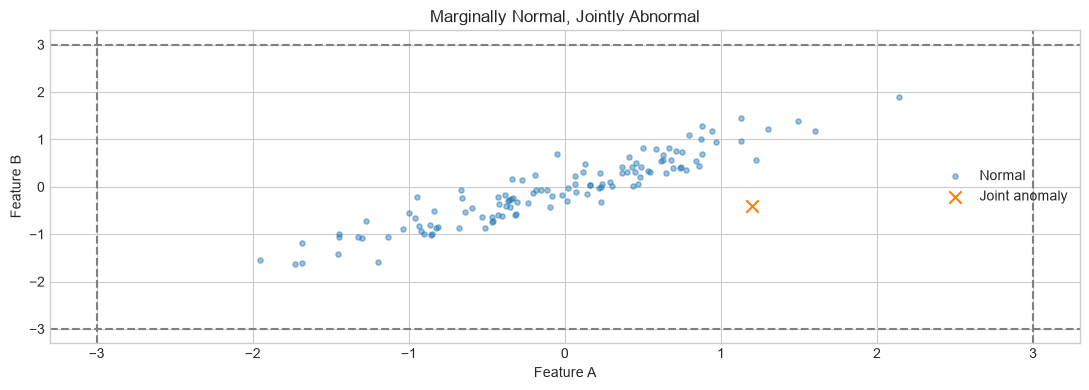

In [6]:
rng = np.random.default_rng(42)
toy_x = rng.normal(0, 1, 120)
toy_y = 0.90 * toy_x + rng.normal(0, 0.25, 120)
toy = np.column_stack([toy_x, toy_y])
toy_query = np.array([[1.2, -0.4]])
print({"query_x_within_3sigma": abs(toy_query[0, 0]) < 3,
       "query_y_within_3sigma": abs(toy_query[0, 1]) < 3})
plt.scatter(toy[:, 0], toy[:, 1], s=14, alpha=0.45, label="Normal")
plt.scatter(*toy_query[0], s=80, marker="x", label="Joint anomaly")
plt.axvline(3, color="gray", linestyle="--"); plt.axvline(-3, color="gray", linestyle="--")
plt.axhline(3, color="gray", linestyle="--"); plt.axhline(-3, color="gray", linestyle="--")
plt.xlabel("Feature A"); plt.ylabel("Feature B"); plt.title("Marginally Normal, Jointly Abnormal")
plt.legend(); plt.tight_layout(); plt.show()

## 5. Mahalanobis distance：global elliptical geometry

如果 normal residual 的中心與 covariance 分別為 $\widehat{\boldsymbol\mu}$、$\widehat{\boldsymbol\Sigma}$，則

$$
D_M^2(\mathbf{x})=(\mathbf{x}-\widehat{\boldsymbol\mu})^\top
\widehat{\boldsymbol\Sigma}^{-1}(\mathbf{x}-\widehat{\boldsymbol\mu}).
$$

它會沿著高變異方向放寬、沿著低變異方向收緊。因此兩個 marginal values 都不極端，仍可能因為破壞 correlation 而得到高分。

依賴的假設是：normal geometry 可以由**單一 global center 與 covariance ellipse**描述。若資料有多個 normal modes、彎曲 manifold，或 covariance 接近 singular，必須特別小心。`EmpiricalCovariance` 是透明的教學起點；production 可比較 shrinkage estimator，例如 `LedoitWolf`。

In [7]:
def fit_mahalanobis(values, shrinkage=False):
    values = np.asarray(values, dtype=float)
    if values.ndim != 2 or len(values) < 2 or not np.isfinite(values).all():
        raise ValueError("Mahalanobis fit requires a finite two-dimensional sample")
    estimator = LedoitWolf() if shrinkage else EmpiricalCovariance()
    return estimator.fit(values)

def mahalanobis_score(model, values):
    values = np.asarray(values, dtype=float)
    if values.ndim != 2 or not np.isfinite(values).all():
        raise ValueError("Mahalanobis score requires finite rows")
    return model.mahalanobis(values)

def max_abs_zscore(values):
    values = np.asarray(values, dtype=float)
    return np.max(np.abs(values), axis=1)

TARGET_FALSE_ONSETS = 7  # 14 天 calibration 對應每天 0.5 次 false onset

def signal_onsets(flags):
    flags = np.asarray(flags, dtype=bool)
    return flags & ~np.r_[False, flags[:-1]]

def calibrate_threshold(scores, target_onsets=7):
    scores = np.asarray(scores, dtype=float)
    if scores.ndim != 1 or not np.isfinite(scores).all():
        raise ValueError("Calibration requires one finite score per timestamp")
    candidates = np.r_[-np.inf, np.unique(scores), np.inf]
    ranked = []
    for threshold in candidates:
        count = int(signal_onsets(scores > threshold).sum())
        ranked.append((abs(count - target_onsets), count > target_onsets, -threshold, threshold))
    return float(min(ranked)[-1])

maha_model = fit_mahalanobis(estimate_scaled)
condition_number = np.linalg.cond(maha_model.covariance_)
print({"covariance_condition_number": round(condition_number, 2)})

{'covariance_condition_number': np.float64(14122.8)}


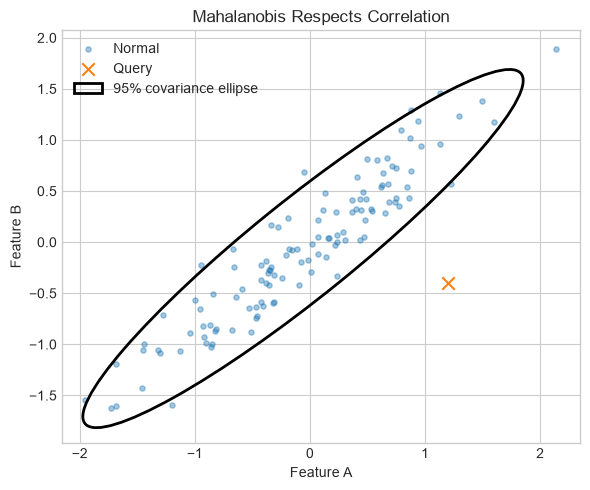

{'manual_D2': 35.259308, 'sklearn_D2': 35.259308}


In [8]:
toy_model = fit_mahalanobis(toy)
centered_query = toy_query[0] - toy_model.location_
manual_d2 = centered_query @ toy_model.precision_ @ centered_query
sklearn_d2 = mahalanobis_score(toy_model, toy_query)[0]

eigvals, eigvecs = np.linalg.eigh(toy_model.covariance_)
order = eigvals.argsort()[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]
angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
ellipse = Ellipse(
    toy_model.location_, 2 * np.sqrt(5.991 * eigvals[0]), 2 * np.sqrt(5.991 * eigvals[1]),
    angle=angle, fill=False, linewidth=2, label="95% covariance ellipse",
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(toy[:, 0], toy[:, 1], s=14, alpha=0.4, label="Normal")
ax.scatter(*toy_query[0], s=80, marker="x", label="Query")
ax.add_patch(ellipse)
ax.set(title="Mahalanobis Respects Correlation", xlabel="Feature A", ylabel="Feature B")
ax.legend(); plt.tight_layout(); plt.show()
print({"manual_D2": round(float(manual_d2), 6), "sklearn_D2": round(float(sklearn_d2), 6)})

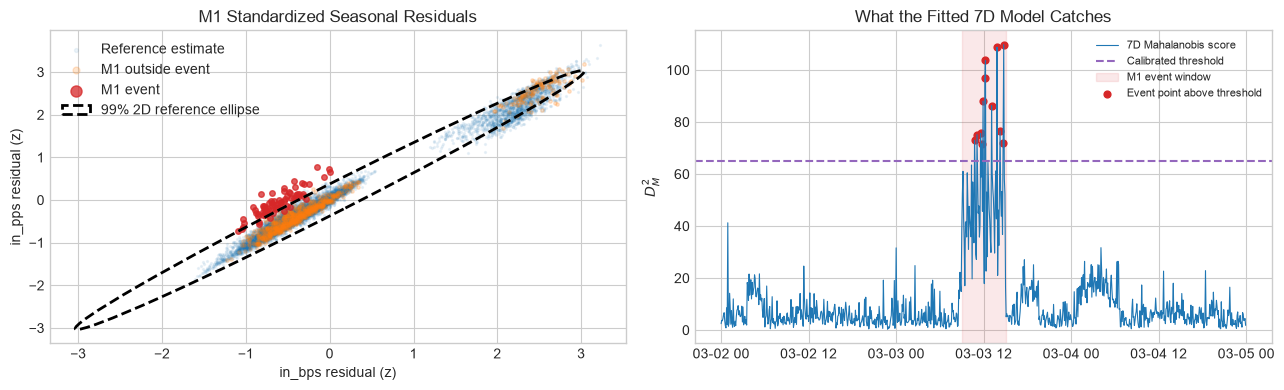

,M1 D2
count,864.000
mean,10.761
std,14.523
min,0.325
50%,5.856
95%,42.712
99%,73.816
max,109.740


In [9]:
def transform_frame(frame):
    residual = seasonal_residuals(frame, seasonal_profiles)
    return scaler.transform(residual)

m1 = scenarios.query("scenario_id == 'M1'").reset_index(drop=True)
m1_scaled = transform_frame(m1)
m1_maha = mahalanobis_score(maha_model, m1_scaled)
estimate_scaled_frame = pd.DataFrame(estimate_scaled, columns=FEATURES)
m1_scaled_frame = pd.DataFrame(m1_scaled, columns=FEATURES)
m1_event = events.query("scenario_id == 'M1'").iloc[0]
m1_inside = m1["timestamp"].ge(m1_event["start_time"]) & m1["timestamp"].lt(m1_event["end_time"])
maha_threshold = calibrate_threshold(
    mahalanobis_score(maha_model, calibration_scaled), TARGET_FALSE_ONSETS
)

m1_pair = ["in_bps", "in_pps"]
m1_pair_model = fit_mahalanobis(estimate_scaled_frame.loc[:, m1_pair])
m1_eigvals, m1_eigvecs = np.linalg.eigh(m1_pair_model.covariance_)
m1_order = m1_eigvals.argsort()[::-1]
m1_eigvals, m1_eigvecs = m1_eigvals[m1_order], m1_eigvecs[:, m1_order]
m1_angle = np.degrees(np.arctan2(m1_eigvecs[1, 0], m1_eigvecs[0, 0]))
m1_ellipse = Ellipse(
    m1_pair_model.location_,
    2 * np.sqrt(9.21034037197618 * m1_eigvals[0]),
    2 * np.sqrt(9.21034037197618 * m1_eigvals[1]),
    angle=m1_angle, fill=False, linewidth=2, linestyle="--",
    label="99% 2D reference ellipse",
)

m1_fig, m1_axes = plt.subplots(1, 2, figsize=(13, 4))
m1_axes[0].scatter(estimate_scaled_frame["in_bps"], estimate_scaled_frame["in_pps"],
                   s=2, alpha=0.08, label="Reference estimate")
m1_axes[0].scatter(m1_scaled_frame.loc[~m1_inside, "in_bps"],
                   m1_scaled_frame.loc[~m1_inside, "in_pps"],
                   s=6, alpha=0.20, label="M1 outside event")
m1_axes[0].scatter(m1_scaled_frame.loc[m1_inside, "in_bps"],
                   m1_scaled_frame.loc[m1_inside, "in_pps"],
                   s=16, alpha=0.75, color="tab:red", label="M1 event")
m1_axes[0].add_patch(m1_ellipse)
m1_axes[0].set(title="M1 Standardized Seasonal Residuals",
               xlabel="in_bps residual (z)", ylabel="in_pps residual (z)")
m1_axes[0].legend(markerscale=2)
m1_axes[1].plot(m1["timestamp"], m1_maha, linewidth=0.8, label="7D Mahalanobis score")
m1_axes[1].axhline(maha_threshold, color="tab:purple", linestyle="--", label="Calibrated threshold")
m1_axes[1].axvspan(m1_event["start_time"], m1_event["end_time"],
                   color="tab:red", alpha=0.10, label="M1 event window")
m1_flags = m1_maha > maha_threshold
m1_axes[1].scatter(m1.loc[m1_inside & m1_flags, "timestamp"],
                   m1_maha[m1_inside & m1_flags], s=24, color="tab:red",
                   label="Event point above threshold")
m1_axes[1].set(title="What the Fitted 7D Model Catches", ylabel=r"$D_M^2$")
m1_axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
display(pd.Series(m1_maha).describe(percentiles=[0.5, 0.95, 0.99]).to_frame("M1 D2").round(3))

In [10]:
def false_onsets_per_day(scores, threshold, days=14):
    return signal_onsets(np.asarray(scores) > threshold).sum() / days

def score_bundle(values):
    return {
        "Max |z|": max_abs_zscore(values),
        "Mahalanobis": mahalanobis_score(maha_model, values),
        "LOF": lof_score(lof_model, values),
        "PCA T2": score_t2(pca_model, values),
        "PCA SPE": score_spe(pca_model, values),
    }

def event_mask(frame, event):
    return frame["timestamp"].ge(event["start_time"]) & frame["timestamp"].lt(event["end_time"])

def event_metrics(frame, flags, event):
    inside = event_mask(frame, event).to_numpy()
    flags = np.asarray(flags, dtype=bool)
    detected = bool(flags[inside].any())
    delay = np.nan
    if detected:
        first_index = np.flatnonzero(flags & inside)[0]
        delay = (frame.loc[first_index, "timestamp"] - event["start_time"]).total_seconds() / 60
    return detected, delay, int(signal_onsets(flags & inside).sum())

### 學生實驗：依序做 feature ablation

只修改下一格的 `STUDENT_M1_FEATURES`，不要修改全域 `FEATURES`。每次換一組後重新執行下一格：

```python
STUDENT_M1_FEATURES = list(FEATURES)
STUDENT_M1_FEATURES = ["in_bps", "in_pps"]
STUDENT_M1_FEATURES = [feature for feature in FEATURES if feature != "in_pps"]
STUDENT_M1_FEATURES = ["in_bps", "out_bps"]
```

| 設定 | 預期觀察 |
|---|---|
| 全部 7 個 features | 約延遲 105 分鐘，12/72 event points 超過 threshold |
| `in_bps + in_pps` | 事件開始即偵測，約 41/72 points 超過 threshold |
| 移除 `in_pps` | M1 無法偵測，0/72 points |
| volume only | 最多偶然抓到 1/72 point，不能視為可靠證據 |

請回答：哪個 normal relationship 被 M1 破壞？為什麼 features 越多不一定越好？

In [11]:
def run_m1_feature_experiment(feature_columns):
    selected = list(feature_columns)
    unknown = sorted(set(selected) - set(FEATURES))
    if not selected or unknown:
        raise ValueError(f"Choose a non-empty subset of FEATURES; unknown={unknown}")
    if len(selected) != len(set(selected)):
        raise ValueError("feature_columns contains duplicates")

    student_scaler = StandardScaler().fit(estimate_residuals.loc[:, selected])
    student_estimate = student_scaler.transform(estimate_residuals.loc[:, selected])
    student_calibration = student_scaler.transform(calibration_residuals.loc[:, selected])
    student_m1 = student_scaler.transform(
        seasonal_residuals(m1, seasonal_profiles, selected)
    )
    student_model = fit_mahalanobis(student_estimate)
    student_threshold = calibrate_threshold(
        mahalanobis_score(student_model, student_calibration), TARGET_FALSE_ONSETS
    )
    student_scores = mahalanobis_score(student_model, student_m1)
    student_flags = student_scores > student_threshold
    detected, delay, onsets = event_metrics(m1, student_flags, m1_event)
    inside = event_mask(m1, m1_event).to_numpy()
    flagged_points = int((student_flags & inside).sum())
    event_points = int(inside.sum())
    return pd.Series({
        "features": ", ".join(selected),
        "feature_count": len(selected),
        "threshold": student_threshold,
        "event_peak_score": float(student_scores[inside].max()),
        "detected": detected,
        "delay_minutes": delay,
        "event_flagged_points": flagged_points,
        "event_flagged_fraction": flagged_points / event_points,
        "event_onsets": onsets,
    })

STUDENT_M1_FEATURES = list(FEATURES)
display(run_m1_feature_experiment(STUDENT_M1_FEATURES).to_frame("M1 experiment"))

,M1 experiment
features,"in_bps, out_bps, in_pps, out_pps, avg_pkt_byte..."
feature_count,7
threshold,65.172001
event_peak_score,109.740112
detected,True
delay_minutes,105.0
event_flagged_points,12
event_flagged_fraction,0.166667
event_onsets,10


In [12]:
STUDENT_M1_FEATURES = ["in_bps", "in_pps"]
display(run_m1_feature_experiment(STUDENT_M1_FEATURES).to_frame("M1 experiment"))

,M1 experiment
features,"in_bps, in_pps"
feature_count,2
threshold,17.773175
event_peak_score,58.477206
detected,True
delay_minutes,0.0
event_flagged_points,41
event_flagged_fraction,0.569444
event_onsets,22


In [26]:
STUDENT_M1_FEATURES = ["in_bps", "out_bps"]
display(run_m1_feature_experiment(STUDENT_M1_FEATURES).to_frame("M1 experiment"))

,M1 experiment
features,"in_bps, out_bps"
feature_count,2
threshold,12.25017
event_peak_score,12.310224
detected,True
delay_minutes,90.0
event_flagged_points,1
event_flagged_fraction,0.013889
event_onsets,1


<details>
<summary><strong>參考解讀（完成作答後再展開）</strong></summary>

1. **M1 破壞哪個 normal relationship？** M1 維持相近的 inbound throughput，卻以較小封包提高 packet rate，因此破壞 `in_bps` 與 `in_pps` 的 joint relationship。異常不一定是單一 feature 極端，而是兩者的組合離開 normal geometry。
2. **為什麼 features 越多不一定越好？** 較弱或無關的維度會增加 covariance estimation 與 normal score 的變異。若每組 features 都用相同 false-onset budget 重新 calibration，threshold 也可能提高，反而稀釋集中在 `in_bps–in_pps` 的訊號。因此 feature count 與偵測品質不是單調關係。

</details>

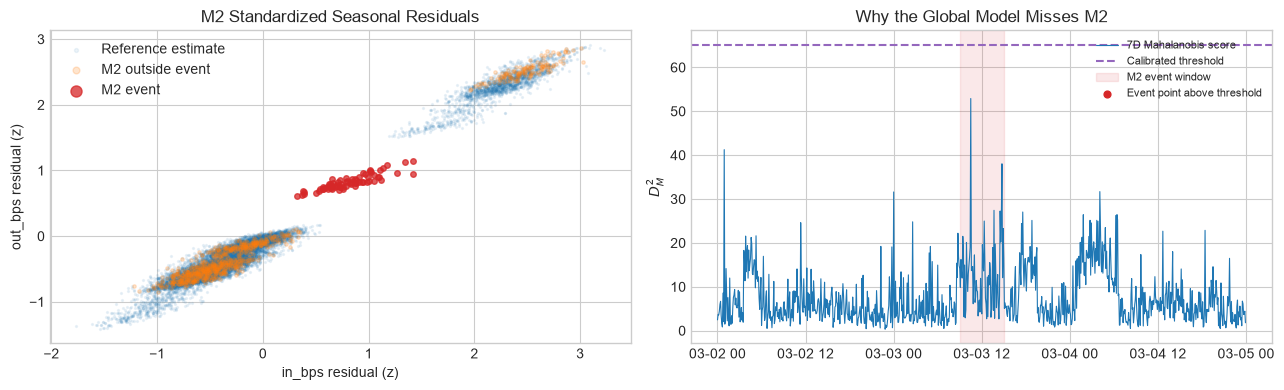

Global ellipse 可能包住兩個 normal modes 之間的稀疏區域。


In [13]:
m2 = scenarios.query("scenario_id == 'M2'").reset_index(drop=True)
m2_scaled = transform_frame(m2)
m2_maha = mahalanobis_score(maha_model, m2_scaled)
m2_scaled_frame = pd.DataFrame(m2_scaled, columns=FEATURES)
m2_event = events.query("scenario_id == 'M2'").iloc[0]
m2_inside = m2["timestamp"].ge(m2_event["start_time"]) & m2["timestamp"].lt(m2_event["end_time"])

m2_fig, m2_axes = plt.subplots(1, 2, figsize=(13, 4))
m2_axes[0].scatter(estimate_scaled_frame["in_bps"], estimate_scaled_frame["out_bps"],
                   s=2, alpha=0.08, label="Reference estimate")
m2_axes[0].scatter(m2_scaled_frame.loc[~m2_inside, "in_bps"],
                   m2_scaled_frame.loc[~m2_inside, "out_bps"],
                   s=6, alpha=0.20, label="M2 outside event")
m2_axes[0].scatter(m2_scaled_frame.loc[m2_inside, "in_bps"],
                   m2_scaled_frame.loc[m2_inside, "out_bps"],
                   s=16, alpha=0.75, color="tab:red", label="M2 event")
m2_axes[0].set(title="M2 Standardized Seasonal Residuals",
               xlabel="in_bps residual (z)", ylabel="out_bps residual (z)")
m2_axes[0].legend(markerscale=2)
m2_axes[1].plot(m2["timestamp"], m2_maha, linewidth=0.8, label="7D Mahalanobis score")
m2_axes[1].axhline(maha_threshold, color="tab:purple", linestyle="--", label="Calibrated threshold")
m2_axes[1].axvspan(m2_event["start_time"], m2_event["end_time"],
                   color="tab:red", alpha=0.10, label="M2 event window")
m2_flags = m2_maha > maha_threshold
m2_axes[1].scatter(m2.loc[m2_inside & m2_flags, "timestamp"],
                   m2_maha[m2_inside & m2_flags], s=24, color="tab:red",
                   label="Event point above threshold")
m2_axes[1].set(title="Why the Global Model Misses M2", ylabel=r"$D_M^2$")
m2_axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Global ellipse 可能包住兩個 normal modes 之間的稀疏區域。")

## 6. 從 kNN 到 LOF：local density geometry

kNN score 可以直接用第 $k$ 個鄰居距離：鄰居越遠，局部越稀疏。但同一個 absolute distance 在 dense mode 與 sparse mode 的意義不同。LOF 比較 query 與其鄰居的 local reachability density：

$$
\operatorname{LOF}_k(\mathbf{x})=
\frac{1}{|N_k(\mathbf{x})|}\sum_{\mathbf{o}\in N_k(\mathbf{x})}
\frac{\operatorname{lrd}_k(\mathbf{o})}{\operatorname{lrd}_k(\mathbf{x})}.
$$

接近 1 表示密度與鄰居類似；較大表示比鄰居稀疏。Lab 使用 `novelty=True`：只在 estimate fit，之後才對 calibration 與 Phase II 新資料呼叫 `score_samples`。

In [14]:
def fit_knn(values, n_neighbors=30):
    values = np.asarray(values, dtype=float)
    if not 1 <= n_neighbors < len(values):
        raise ValueError("n_neighbors must be smaller than the reference sample")
    return NearestNeighbors(n_neighbors=n_neighbors).fit(values)

def knn_score(model, values):
    distances, _ = model.kneighbors(np.asarray(values, dtype=float))
    return distances[:, -1]

def fit_lof(values, n_neighbors=30):
    values = np.asarray(values, dtype=float)
    if not 1 <= n_neighbors < len(values):
        raise ValueError("n_neighbors must be smaller than the reference sample")
    return LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True).fit(values)

def lof_score(model, values):
    return -model.score_samples(np.asarray(values, dtype=float))

knn_model = fit_knn(estimate_scaled, n_neighbors=30)
lof_model = fit_lof(estimate_scaled, n_neighbors=30)
print({"k": 30, "fit_rows": len(estimate_scaled), "novelty_mode": lof_model.novelty})

{'k': 30, 'fit_rows': 12096, 'novelty_mode': True}


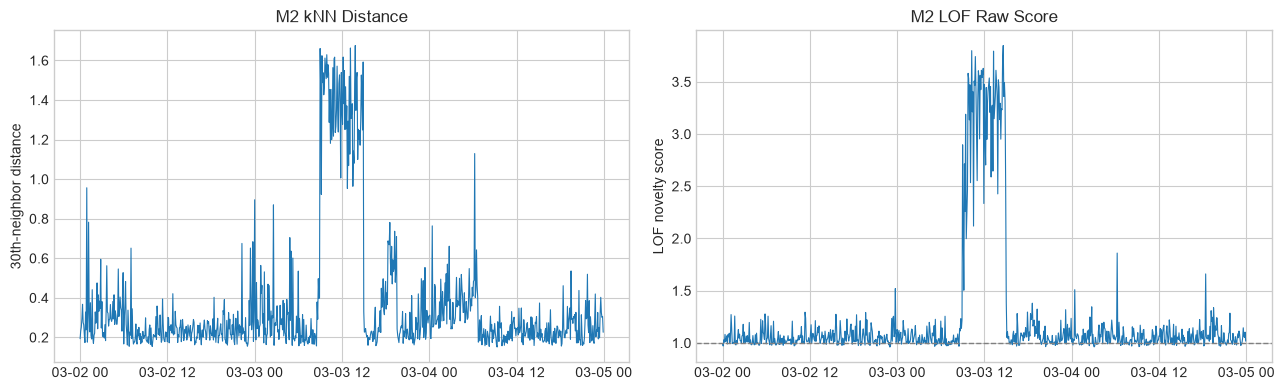

,kNN,LOF
count,864.000,864.000
mean,0.370,1.234
std,0.330,0.603
min,0.151,0.961
25%,0.204,1.004
50%,0.252,1.043
75%,0.345,1.114
max,1.676,3.847


In [15]:
m2_knn = knn_score(knn_model, m2_scaled)
m2_lof = lof_score(lof_model, m2_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(m2["timestamp"], m2_knn, linewidth=0.8)
axes[0].set(title="M2 kNN Distance", ylabel="30th-neighbor distance")
axes[1].plot(m2["timestamp"], m2_lof, linewidth=0.8)
axes[1].axhline(1, color="gray", linestyle="--", linewidth=1)
axes[1].set(title="M2 LOF Raw Score", ylabel="LOF novelty score")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"kNN": m2_knn, "LOF": m2_lof}).describe().round(3))

### 學生實驗：改變 LOF neighborhood scale

依序把下一格的 `STUDENT_LOF_K` 設為 `10`、`30`、`100`，每次重新執行並比較 score curve、threshold 與 event hits。

| K | 預期觀察 |
|---:|---|
| 10 | peak 約 4.70、70/72 event points、3 onsets；較 local、較敏感，也較零碎 |
| 30 | peak 約 3.85、71/72 event points、2 onsets |
| 100 | peak 約 3.23、71/72 event points、2 onsets；較平滑，局部 peak 較低 |

三組 K 在各自重新 calibration 後都能立即偵測 M2。因此這裡不是尋找唯一正確的 K，而是觀察 neighborhood scale 如何改變 score 的局部敏感度與平滑程度。

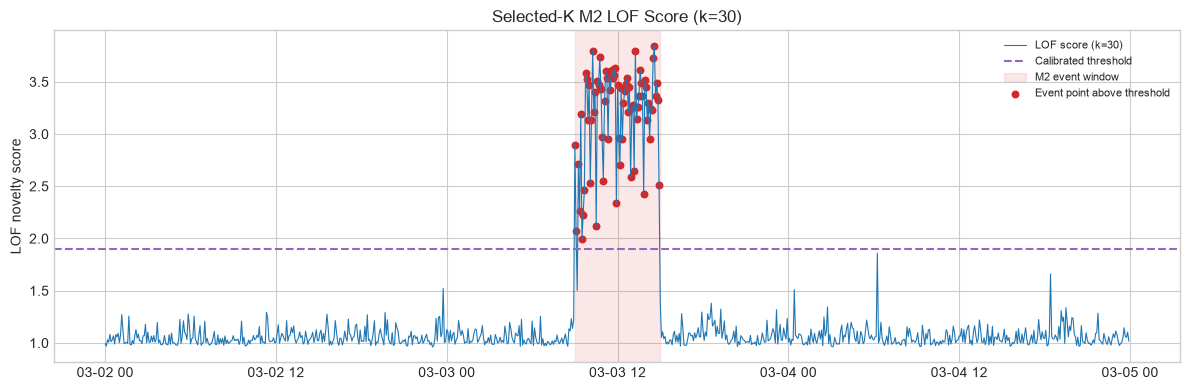

,LOF experiment
neighbors,30
threshold,1.903827
calibration_false_onsets_per_day,0.5
M2_event_peak_score,3.847199
M2_detected,True
M2_delay_minutes,0.0
M2_event_flagged_points,71
M2_event_flagged_fraction,0.986111
M2_event_onsets,2


In [16]:
def evaluate_m2_lof_k(n_neighbors):
    if not 1 <= n_neighbors < len(estimate_scaled):
        raise ValueError("n_neighbors must be between 1 and estimate rows - 1")
    model = fit_lof(estimate_scaled, n_neighbors=n_neighbors)
    calibration_scores = lof_score(model, calibration_scaled)
    threshold = calibrate_threshold(calibration_scores, TARGET_FALSE_ONSETS)
    scores = lof_score(model, m2_scaled)
    flags = scores > threshold
    detected, delay, onsets = event_metrics(m2, flags, m2_event)
    inside = event_mask(m2, m2_event).to_numpy()
    flagged_points = int((flags & inside).sum())
    event_points = int(inside.sum())
    summary = pd.Series({
        "neighbors": n_neighbors,
        "threshold": threshold,
        "calibration_false_onsets_per_day": false_onsets_per_day(
            calibration_scores, threshold
        ),
        "M2_event_peak_score": float(scores[inside].max()),
        "M2_detected": detected,
        "M2_delay_minutes": delay,
        "M2_event_flagged_points": flagged_points,
        "M2_event_flagged_fraction": flagged_points / event_points,
        "M2_event_onsets": onsets,
    })
    return {"summary": summary, "scores": scores,
            "flags": flags, "threshold": threshold}

STUDENT_LOF_K = 30
student_lof_result = evaluate_m2_lof_k(STUDENT_LOF_K)
student_m2_lof = student_lof_result["scores"]
student_lof_flags = student_lof_result["flags"]
student_lof_threshold = student_lof_result["threshold"]
m2_inside = event_mask(m2, m2_event)

student_lof_fig, student_lof_ax = plt.subplots(figsize=(12, 4))
student_lof_ax.plot(m2["timestamp"], student_m2_lof, linewidth=0.8,
                    label=f"LOF score (k={STUDENT_LOF_K})")
student_lof_ax.axhline(student_lof_threshold, color="tab:purple",
                       linestyle="--", label="Calibrated threshold")
student_lof_ax.axvspan(m2_event["start_time"], m2_event["end_time"],
                       color="tab:red", alpha=0.10, label="M2 event window")
student_lof_ax.scatter(
    m2.loc[m2_inside & student_lof_flags, "timestamp"],
    student_m2_lof[m2_inside & student_lof_flags],
    s=22, color="tab:red", label="Event point above threshold",
)
student_lof_ax.set(title=f"Selected-K M2 LOF Score (k={STUDENT_LOF_K})",
                   ylabel="LOF novelty score")
student_lof_ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(student_lof_result["summary"].to_frame("LOF experiment"))

# 問題：K 變大後，score curve 的局部 peak 與零碎程度如何改變？

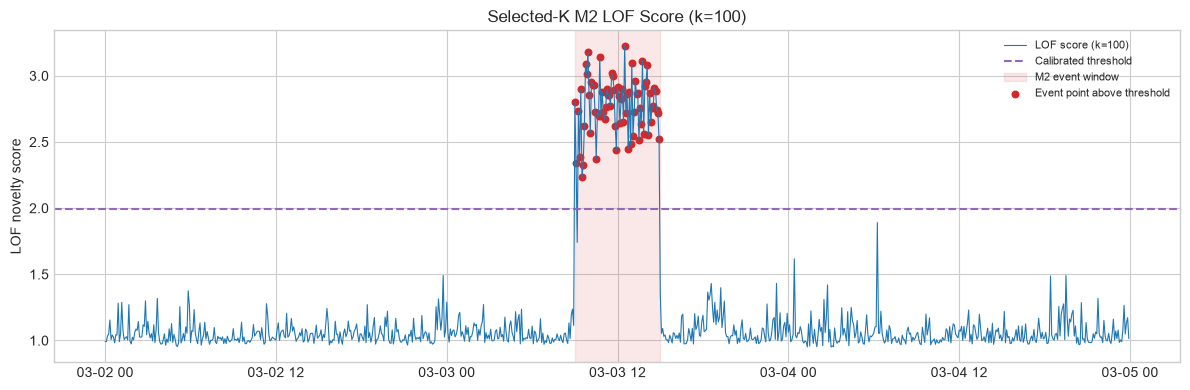

,LOF experiment
neighbors,100
threshold,1.991094
calibration_false_onsets_per_day,0.5
M2_event_peak_score,3.228387
M2_detected,True
M2_delay_minutes,0.0
M2_event_flagged_points,71
M2_event_flagged_fraction,0.986111
M2_event_onsets,2


In [27]:
STUDENT_LOF_K = 100
student_lof_result = evaluate_m2_lof_k(STUDENT_LOF_K)
student_m2_lof = student_lof_result["scores"]
student_lof_flags = student_lof_result["flags"]
student_lof_threshold = student_lof_result["threshold"]
m2_inside = event_mask(m2, m2_event)

student_lof_fig, student_lof_ax = plt.subplots(figsize=(12, 4))
student_lof_ax.plot(m2["timestamp"], student_m2_lof, linewidth=0.8,
                    label=f"LOF score (k={STUDENT_LOF_K})")
student_lof_ax.axhline(student_lof_threshold, color="tab:purple",
                       linestyle="--", label="Calibrated threshold")
student_lof_ax.axvspan(m2_event["start_time"], m2_event["end_time"],
                       color="tab:red", alpha=0.10, label="M2 event window")
student_lof_ax.scatter(
    m2.loc[m2_inside & student_lof_flags, "timestamp"],
    student_m2_lof[m2_inside & student_lof_flags],
    s=22, color="tab:red", label="Event point above threshold",
)
student_lof_ax.set(title=f"Selected-K M2 LOF Score (k={STUDENT_LOF_K})",
                   ylabel="LOF novelty score")
student_lof_ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(student_lof_result["summary"].to_frame("LOF experiment"))

# 問題：K 變大後，score curve 的局部 peak 與零碎程度如何改變？

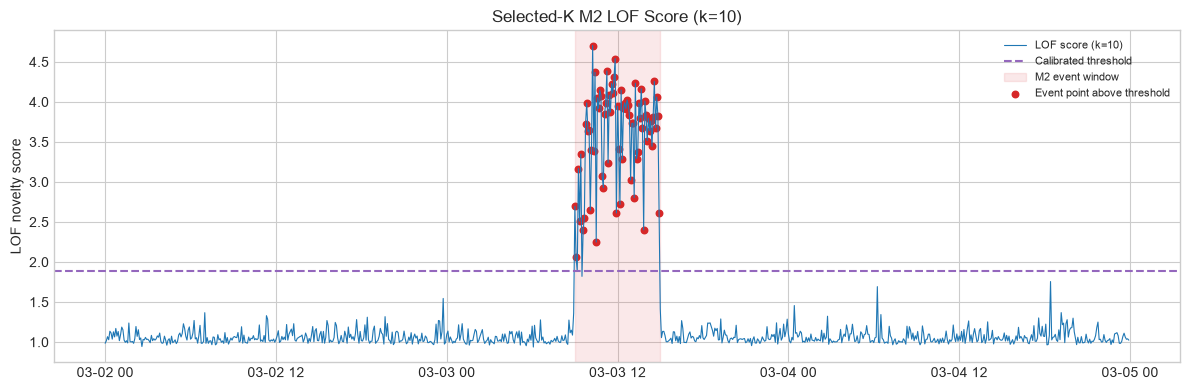

,LOF experiment
neighbors,10
threshold,1.888685
calibration_false_onsets_per_day,0.5
M2_event_peak_score,4.703536
M2_detected,True
M2_delay_minutes,0.0
M2_event_flagged_points,70
M2_event_flagged_fraction,0.972222
M2_event_onsets,3


In [28]:
STUDENT_LOF_K = 10
student_lof_result = evaluate_m2_lof_k(STUDENT_LOF_K)
student_m2_lof = student_lof_result["scores"]
student_lof_flags = student_lof_result["flags"]
student_lof_threshold = student_lof_result["threshold"]
m2_inside = event_mask(m2, m2_event)

student_lof_fig, student_lof_ax = plt.subplots(figsize=(12, 4))
student_lof_ax.plot(m2["timestamp"], student_m2_lof, linewidth=0.8,
                    label=f"LOF score (k={STUDENT_LOF_K})")
student_lof_ax.axhline(student_lof_threshold, color="tab:purple",
                       linestyle="--", label="Calibrated threshold")
student_lof_ax.axvspan(m2_event["start_time"], m2_event["end_time"],
                       color="tab:red", alpha=0.10, label="M2 event window")
student_lof_ax.scatter(
    m2.loc[m2_inside & student_lof_flags, "timestamp"],
    student_m2_lof[m2_inside & student_lof_flags],
    s=22, color="tab:red", label="Event point above threshold",
)
student_lof_ax.set(title=f"Selected-K M2 LOF Score (k={STUDENT_LOF_K})",
                   ylabel="LOF novelty score")
student_lof_ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(student_lof_result["summary"].to_frame("LOF experiment"))

# 問題：K 變大後，score curve 的局部 peak 與零碎程度如何改變？

## 7. PCA：representation 不是 detector

PCA 先找 normal covariance 的主要方向：

$$
\mathbf{t}=\mathbf{P}^\top(\mathbf{x}-\boldsymbol\mu),
\qquad \widehat{\mathbf{x}}=\boldsymbol\mu+\mathbf{P}\mathbf{t}.
$$

投影後仍要決定下游 score。本 Lab 用兩個互補的 monitoring statistics：

$$
T^2=\sum_{j=1}^{a}\frac{t_j^2}{\lambda_j},
\qquad
SPE=\|\mathbf{x}-\widehat{\mathbf{x}}\|_2^2.
$$

$T^2$ 問「沿 learned subspace 是否走得太遠」；SPE（Q statistic）問「是否離開 learned subspace」。選幾個 components 會改變兩者的分工，因此不能只把 90% explained variance 當成自然定律。

In [17]:
def minimum_components_for_variance(values, target=0.90):
    if not 0 < target <= 1:
        raise ValueError("target must be in (0, 1]")
    full = PCA().fit(np.asarray(values, dtype=float))
    return int(np.searchsorted(np.cumsum(full.explained_variance_ratio_), target) + 1)

def fit_pca_monitor(values, n_components):
    values = np.asarray(values, dtype=float)
    if not 1 <= n_components <= values.shape[1]:
        raise ValueError("invalid n_components")
    return PCA(n_components=n_components).fit(values)

def score_t2(model, values):
    scores = model.transform(np.asarray(values, dtype=float))
    return np.sum(scores ** 2 / model.explained_variance_, axis=1)

def score_spe(model, values):
    values = np.asarray(values, dtype=float)
    reconstruction = model.inverse_transform(model.transform(values))
    return np.sum((values - reconstruction) ** 2, axis=1)

n_components_90 = minimum_components_for_variance(estimate_scaled, target=0.90)
pca_model = fit_pca_monitor(estimate_scaled, n_components_90)
pca_thresholds = {
    "PCA T2": calibrate_threshold(
        score_t2(pca_model, calibration_scaled), TARGET_FALSE_ONSETS
    ),
    "PCA SPE": calibrate_threshold(
        score_spe(pca_model, calibration_scaled), TARGET_FALSE_ONSETS
    ),
}

def plot_pca_scenario(frame, scenario_id, score_map, threshold_map=None):
    event = events.query("scenario_id == @scenario_id").iloc[0]
    inside_event = event_mask(frame, event).to_numpy()
    active_thresholds = pca_thresholds if threshold_map is None else threshold_map
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    for axis, (detector, scores) in zip(axes, score_map.items()):
        scores_array = np.asarray(scores)
        threshold = active_thresholds[detector]
        selected = inside_event & (scores_array > threshold)
        axis.plot(frame["timestamp"], scores_array, linewidth=0.8, label="Score")
        axis.axhline(
            threshold, color="tab:purple", linestyle="--",
            label="Calibrated threshold",
        )
        axis.axvspan(
            event["start_time"], event["end_time"],
            color="tab:red", alpha=0.10, label=f"{scenario_id} event",
        )
        axis.scatter(
            frame.loc[selected, "timestamp"], scores_array[selected],
            color="tab:red", s=18, label="Flagged in event", zorder=3,
        )
        axis.set(title=f"{scenario_id} {detector}", ylabel=detector.removeprefix("PCA "))
        axis.legend(loc="upper right", fontsize=8)
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    return fig, axes

print({"components_for_90_percent": n_components_90})

{'components_for_90_percent': 1}


,component,explained_ratio,cumulative_ratio
0,1,0.9191,0.9191
1,2,0.0554,0.9745
2,3,0.0206,0.9951
3,4,0.0025,0.9976
4,5,0.0017,0.9993
5,6,0.0006,0.9999
6,7,0.0001,1.0000


,PC1,PC2,PC3
in_bps,0.390,0.117,-0.286
out_bps,0.387,0.240,-0.279
in_pps,0.390,-0.013,-0.309
out_pps,0.389,0.185,-0.266
avg_pkt_bytes,0.353,0.552,0.745
broadcast_ratio,-0.368,0.542,-0.247
multicast_ratio,-0.368,0.544,-0.243


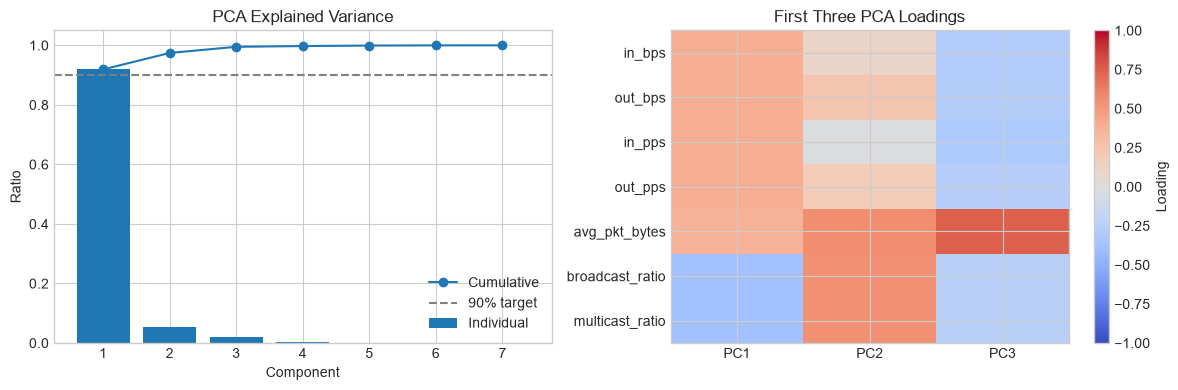

In [18]:
full_pca = PCA().fit(estimate_scaled)
explained = pd.DataFrame({
    "component": np.arange(1, len(FEATURES) + 1),
    "explained_ratio": full_pca.explained_variance_ratio_,
    "cumulative_ratio": np.cumsum(full_pca.explained_variance_ratio_),
})
loadings = pd.DataFrame(full_pca.components_.T, index=FEATURES,
                        columns=[f"PC{i}" for i in range(1, len(FEATURES) + 1)])
display(explained.round(4))
display(loadings.iloc[:, :3].round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(explained["component"], explained["explained_ratio"], label="Individual")
axes[0].plot(explained["component"], explained["cumulative_ratio"], marker="o", label="Cumulative")
axes[0].axhline(0.90, color="gray", linestyle="--", label="90% target")
axes[0].set(title="PCA Explained Variance", xlabel="Component", ylabel="Ratio", ylim=(0, 1.05))
axes[0].legend()
image = axes[1].imshow(loadings.iloc[:, :3], vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
axes[1].set_xticks(range(3), loadings.columns[:3]); axes[1].set_yticks(range(len(FEATURES)), FEATURES)
axes[1].set_title("First Three PCA Loadings")
fig.colorbar(image, ax=axes[1], label="Loading")
plt.tight_layout(); plt.show()

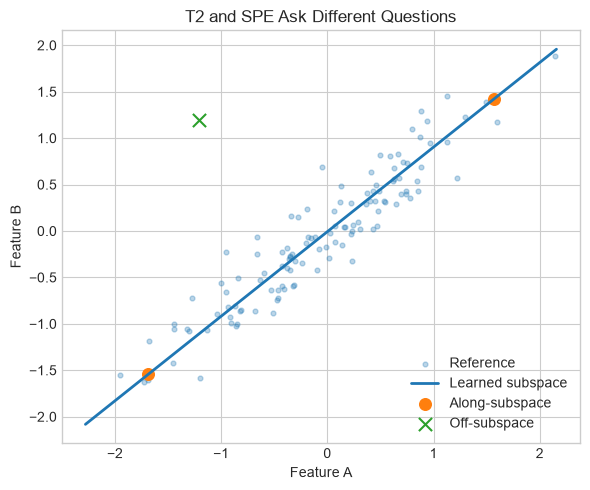

,point,T2,SPE
0,along_positive,4.408,0.00
1,along_negative,4.408,0.00
2,off_subspace,0.000,2.89


In [19]:
toy_pca = PCA(n_components=1).fit(toy)
origin = toy_pca.mean_
direction = toy_pca.components_[0]
normal = np.array([origin + 2.2 * direction, origin - 2.2 * direction])
orthogonal = np.array([-direction[1], direction[0]])
off_point = origin + 1.7 * orthogonal

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(toy[:, 0], toy[:, 1], s=12, alpha=0.3, label="Reference")
line = np.vstack([origin - 3 * direction, origin + 3 * direction])
ax.plot(line[:, 0], line[:, 1], linewidth=2, label="Learned subspace")
ax.scatter(normal[:, 0], normal[:, 1], marker="o", s=70, label="Along-subspace")
ax.scatter(*off_point, marker="x", s=90, label="Off-subspace")
ax.set(title="T2 and SPE Ask Different Questions", xlabel="Feature A", ylabel="Feature B")
ax.legend(); plt.tight_layout(); plt.show()
display(pd.DataFrame({
    "point": ["along_positive", "along_negative", "off_subspace"],
    "T2": score_t2(toy_pca, np.vstack([normal, off_point])),
    "SPE": score_spe(toy_pca, np.vstack([normal, off_point])),
}).round(3))

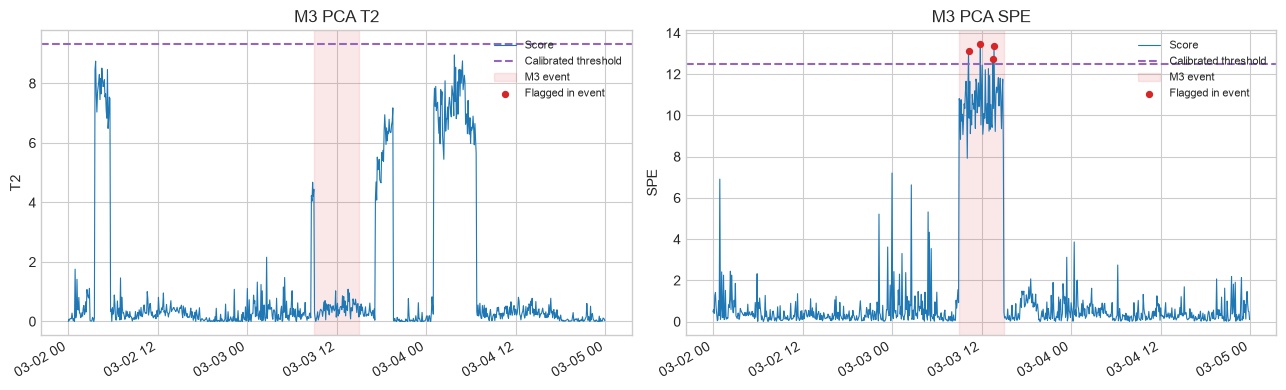

In [20]:
m3 = scenarios.query("scenario_id == 'M3'").reset_index(drop=True)
m3_scaled = transform_frame(m3)
m3_t2 = score_t2(pca_model, m3_scaled)
m3_spe = score_spe(pca_model, m3_scaled)

m3_fig, m3_axes = plot_pca_scenario(
    m3, "M3", {"PCA T2": m3_t2, "PCA SPE": m3_spe}
)
plt.show()

### M3 結論：離開 subspace，SPE 才看得到

M3 改變 L2 composition，但沿主要 traffic direction 的位置沒有特別極端。因此 $T^2$ 沒有越過門檻；SPE 則因 reconstruction residual 增加而有反應。這是 **off-subspace anomaly**。

不過預設結果只有 **4/72** 個事件點越線，且形成 **4 個分離 onsets**，第一個命中延遲 **75 分鐘**。因此它支持「SPE 比 $T^2$ 適合這種 geometry」，但還不能稱為穩健的 operational detection。

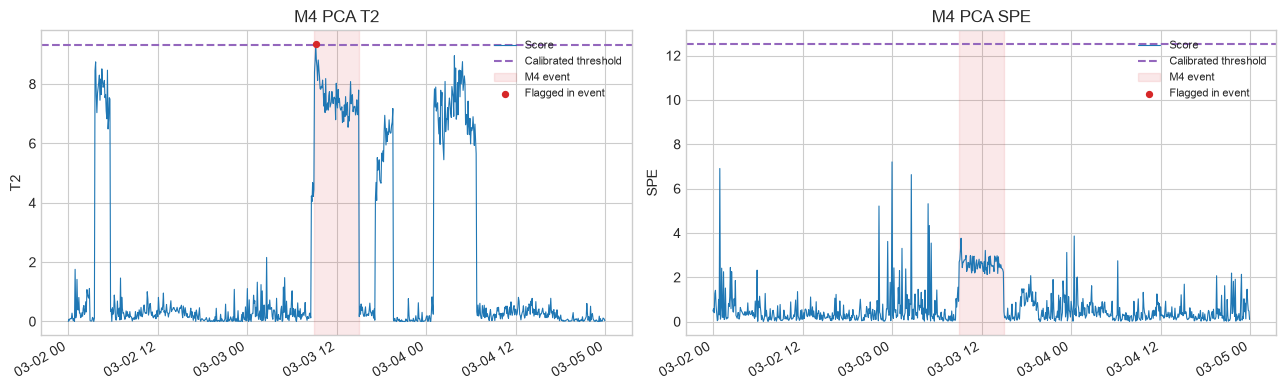

In [21]:
m4 = scenarios.query("scenario_id == 'M4'").reset_index(drop=True)
m4_scaled = transform_frame(m4)
m4_t2 = score_t2(pca_model, m4_scaled)
m4_spe = score_spe(pca_model, m4_scaled)

m4_fig, m4_axes = plot_pca_scenario(
    m4, "M4", {"PCA T2": m4_t2, "PCA SPE": m4_spe}
)
plt.show()

### M4 結論：沿 subspace 走太遠，$T^2$ 才看得到

M4 仍靠近 learned subspace，reconstruction error 不大，因此 SPE 沒有越過門檻；但它沿 retained direction 超出 normal operating envelope，使 $T^2$ 有反應。這是 **along-subspace anomaly**。

不過預設結果只有 **1/72** 個事件點越線，第一個命中延遲 **10 分鐘**。所以 `detected=True` 只是 point-wise hit，不能單獨稱為成功；實務上仍需 persistence 或 run rule。

所以 $T^2$ 與 SPE 是互補的監控統計量：前者看 retained subspace 內的 extent，後者看離開 subspace 的 residual，不能只選一個就期待涵蓋所有 geometry。

In [22]:
calibration_scores = score_bundle(calibration_scaled)
thresholds = {
    name: calibrate_threshold(values, TARGET_FALSE_ONSETS)
    for name, values in calibration_scores.items()
}
calibration_table = pd.DataFrame({
    "threshold": thresholds,
    "false_onsets_per_day": {
        name: false_onsets_per_day(values, thresholds[name])
        for name, values in calibration_scores.items()
    },
})
display(calibration_table.round(4))

scenario_scores = {}
for scenario_id, part in scenarios.groupby("scenario_id", sort=False):
    scenario_scores[scenario_id] = score_bundle(transform_frame(part.reset_index(drop=True)))

,threshold,false_onsets_per_day
Max |z|,3.7229,0.5
Mahalanobis,65.1720,0.5
LOF,1.9038,0.5
PCA T2,9.3122,0.5
PCA SPE,12.5065,0.5


In [23]:
rows = []
for scenario_id, part in scenarios.groupby("scenario_id", sort=False):
    part = part.reset_index(drop=True)
    event = events.query("scenario_id == @scenario_id").iloc[0]
    for detector, values in scenario_scores[scenario_id].items():
        detected, delay, onsets = event_metrics(part, values > thresholds[detector], event)
        rows.append({"scenario": scenario_id, "detector": detector, "detected": detected,
                     "delay_minutes": delay, "event_onsets": onsets})
scorecard = pd.DataFrame(rows)
display(scorecard.pivot(index="scenario", columns="detector", values="detected"))
display(scorecard.pivot(index="scenario", columns="detector", values="delay_minutes"))

budget_rows = []
for target in (3, 7, 14):
    for detector, calibration_values in calibration_scores.items():
        threshold = calibrate_threshold(calibration_values, target)
        hits = 0
        for scenario_id, part in scenarios.groupby("scenario_id", sort=False):
            event = events.query("scenario_id == @scenario_id").iloc[0]
            hits += event_metrics(part.reset_index(drop=True),
                                  scenario_scores[scenario_id][detector] > threshold, event)[0]
        budget_rows.append({"target_onsets_14d": target, "detector": detector,
                            "detected_scenarios": hits})
budget_table = pd.DataFrame(budget_rows)
display(budget_table.pivot(index="detector", columns="target_onsets_14d", values="detected_scenarios"))

detector,LOF,Mahalanobis,Max |z|,PCA SPE,PCA T2
scenario,,,,,
M1,True,True,False,False,False
M2,True,False,False,False,False
M3,True,True,False,True,False
M4,True,True,False,False,True


detector,LOF,Mahalanobis,Max |z|,PCA SPE,PCA T2
scenario,,,,,
M1,190.0,105.0,NaN,NaN,NaN
M2,0.0,NaN,NaN,NaN,NaN
M3,0.0,0.0,NaN,75.0,NaN
M4,0.0,10.0,NaN,NaN,10.0


target_onsets_14d,3,7,14
detector,,,
LOF,4,4,4
Mahalanobis,3,3,4
Max |z|,0,0,2
PCA SPE,0,1,1
PCA T2,0,1,1


### 學生實驗：調整 One-Class SVM 的 normal boundary

SVDD 在 feature space 尋找包住 normal data 的緊密 boundary；One-Class SVM 則估計 normal distribution 的 support。兩者在本課都回答「新點是否落在 normal boundary 外」，因此用 scikit-learn 的 One-Class SVM 體驗 kernel boundary，不另加 SVDD 套件，也不把它加入 canonical scorecard。

只修改下一格的 `STUDENT_OCSVM_NU` 與 `STUDENT_OCSVM_GAMMA`：

- `nu` 的範圍是 $(0,1]$。它是 training errors fraction 的上界，也是 support vectors fraction 的下界。較大的 `nu` 允許更多 reference points 落在 learned support 外，也要求更多 support vectors；重新校準 threshold 後，偵測敏感度不一定隨 `nu` 單調增加。
- RBF kernel 為 $K(x,x')=\exp(-\gamma\lVert x-x'\rVert^2)$。`gamma` 小時影響範圍較廣、boundary 較平滑；`gamma` 大時較局部、boundary 較靈活。`gamma="scale"` 代表 $1/(n_{features}\operatorname{Var}(X))$。

**建議學生依序執行**

1. 固定 `STUDENT_OCSVM_GAMMA = "scale"`，依序將 `STUDENT_OCSVM_NU` 設為 `0.001`、`0.01`、`0.1`。
2. 固定 `STUDENT_OCSVM_NU = 0.01`，依序將 `STUDENT_OCSVM_GAMMA` 設為 `0.01`、`0.1`、`1.0`。
3. 每次看 M1–M4 的紅點、`event_flagged_points` 與 `event_onsets`。所有設定都重新用 calibration reference 選 threshold，所以不要直接比較不同設定的 raw score 或 threshold 數值。

**預期觀察**

- `nu=0.001, gamma="scale"`：M3、M4 約為 72/72 且連續命中；M1、M2 只有少量零碎點。
- `nu=0.01, gamma="scale"`：M3 約 72/72；M4 約 69/72、4 onsets；M1、M2 各約 1 點。
- `nu=0.1, gamma="scale"`：主要只命中 M3。
- 固定 `nu=0.01` 時，`gamma=0.01` 的 M3 約 21/72、16 onsets；`gamma=0.1` 的 M4 約 59/72、14 onsets；`gamma=1.0` 會大量命中 M2–M4。

`16 onsets` 表示命中的點被切成 16 段 alarm bursts，證據較零碎、容易造成 flapping；不是完全沒用，但 operational alert quality 較差。同樣地，`detected=True` 若只靠一個孤立點，不能單獨稱為成功。

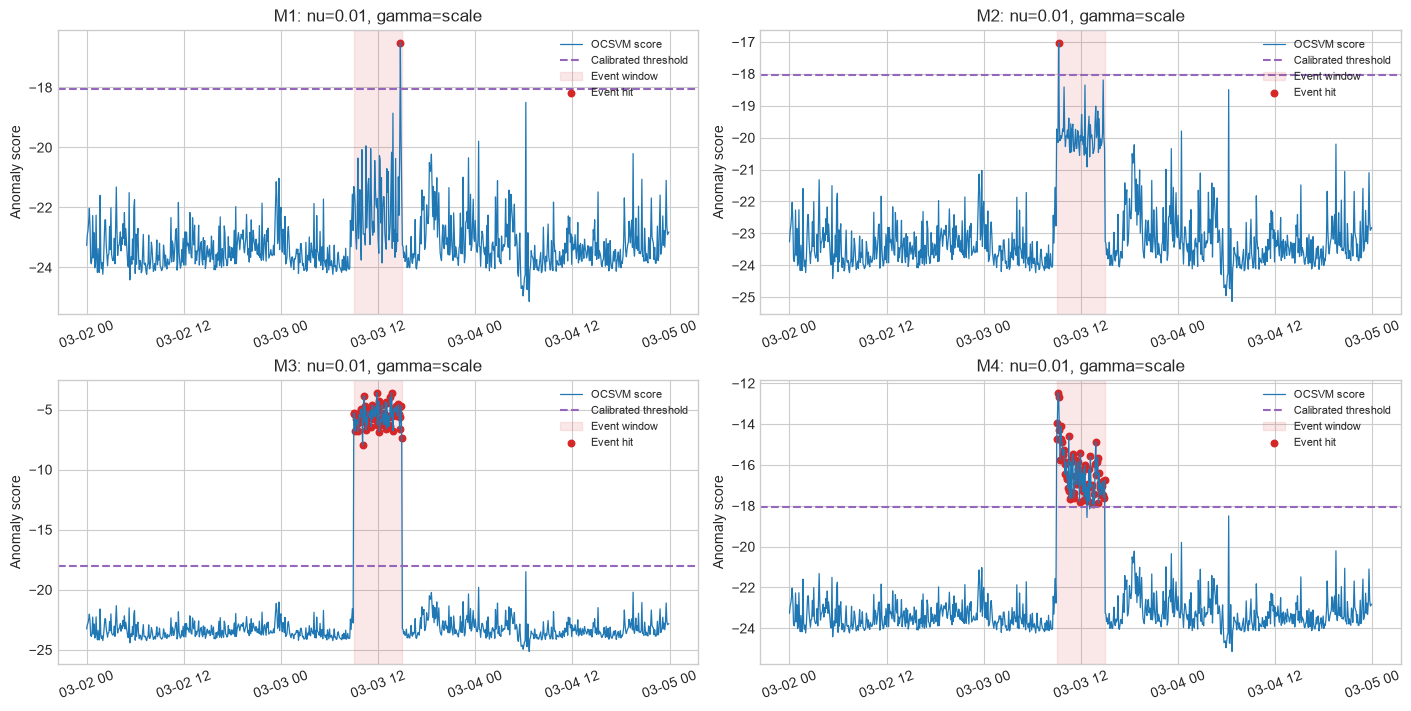

,scenario,nu,gamma,support_vector_fraction,threshold,calibration_false_onsets_per_day,event_peak_score,detected,delay_minutes,event_flagged_points,event_flagged_fraction,event_onsets
0,M1,0.01,scale,0.011,-18.047,0.5,-16.509,True,345.0,1,0.014,1
1,M2,0.01,scale,0.011,-18.047,0.5,-17.025,True,15.0,1,0.014,1
2,M3,0.01,scale,0.011,-18.047,0.5,-3.604,True,0.0,72,1.000,1
3,M4,0.01,scale,0.011,-18.047,0.5,-12.465,True,0.0,69,0.958,4


In [24]:
def evaluate_ocsvm(nu, gamma):
    numeric_types = (int, float, np.integer, np.floating)
    if (
        isinstance(nu, (bool, np.bool_))
        or not isinstance(nu, numeric_types)
        or not np.isfinite(nu)
        or not 0 < nu <= 1
    ):
        raise ValueError("STUDENT_OCSVM_NU 必須是 (0, 1] 內的有限實數")

    named_gamma = isinstance(gamma, str) and gamma in {"scale", "auto"}
    numeric_gamma = (
        not isinstance(gamma, (bool, np.bool_))
        and isinstance(gamma, numeric_types)
        and np.isfinite(gamma)
        and gamma > 0
    )
    if not (named_gamma or numeric_gamma):
        raise ValueError(
            'STUDENT_OCSVM_GAMMA 必須是 "scale"、"auto" 或正的有限實數'
        )

    model_gamma = gamma if named_gamma else float(gamma)
    model = OneClassSVM(nu=float(nu), gamma=model_gamma).fit(estimate_scaled)
    calibration_scores = -model.score_samples(calibration_scaled)
    threshold = calibrate_threshold(calibration_scores, TARGET_FALSE_ONSETS)
    support_fraction = len(model.support_) / len(estimate_scaled)
    calibration_false_onsets = false_onsets_per_day(
        calibration_scores, threshold
    )

    scenario_scores = {}
    rows = []
    for scenario_id, part in scenarios.groupby("scenario_id", sort=False):
        part = part.reset_index(drop=True)
        event = events.query("scenario_id == @scenario_id").iloc[0]
        scores = -model.score_samples(transform_frame(part))
        flags = scores > threshold
        inside = event_mask(part, event).to_numpy()
        detected, delay, onsets = event_metrics(part, flags, event)
        flagged_points = int(flags[inside].sum())
        scenario_scores[scenario_id] = scores
        rows.append({
            "scenario": scenario_id,
            "nu": float(nu),
            "gamma": model_gamma,
            "support_vector_fraction": support_fraction,
            "threshold": threshold,
            "calibration_false_onsets_per_day": calibration_false_onsets,
            "event_peak_score": float(np.max(scores[inside])),
            "detected": detected,
            "delay_minutes": delay,
            "event_flagged_points": flagged_points,
            "event_flagged_fraction": flagged_points / int(inside.sum()),
            "event_onsets": onsets,
        })

    return {
        "model": model,
        "calibration_scores": calibration_scores,
        "threshold": threshold,
        "scenario_scores": scenario_scores,
        "summary": pd.DataFrame(rows),
    }


RUN_OCSVM_EXPERIMENT = True
STUDENT_OCSVM_NU = 0.01
STUDENT_OCSVM_GAMMA = "scale"

if RUN_OCSVM_EXPERIMENT:
    ocsvm_result = evaluate_ocsvm(
        STUDENT_OCSVM_NU, STUDENT_OCSVM_GAMMA
    )
    ocsvm_fig, ocsvm_axes = plt.subplots(
        2, 2, figsize=(14, 7), constrained_layout=True
    )
    for axis, scenario_id in zip(
        ocsvm_axes.flat, ("M1", "M2", "M3", "M4")
    ):
        part = scenarios.query(
            "scenario_id == @scenario_id"
        ).reset_index(drop=True)
        event = events.query("scenario_id == @scenario_id").iloc[0]
        scores = ocsvm_result["scenario_scores"][scenario_id]
        threshold = ocsvm_result["threshold"]
        inside = event_mask(part, event).to_numpy()
        event_hits = inside & (scores > threshold)

        axis.plot(
            part["timestamp"], scores, linewidth=0.9, label="OCSVM score"
        )
        axis.axhline(
            threshold, color="tab:purple", linestyle="--",
            label="Calibrated threshold"
        )
        axis.axvspan(
            event["start_time"], event["end_time"],
            color="tab:red", alpha=0.10, label="Event window"
        )
        axis.scatter(
            part.loc[event_hits, "timestamp"], scores[event_hits],
            s=22, color="tab:red", label="Event hit"
        )
        axis.set_title(
            f"{scenario_id}: nu={STUDENT_OCSVM_NU}, "
            f"gamma={STUDENT_OCSVM_GAMMA}"
        )
        axis.set_ylabel("Anomaly score")
        axis.legend(fontsize=8)
        axis.tick_params(axis="x", rotation=20)

    plt.show()
    display(ocsvm_result["summary"].round(3))
else:
    print(
        "選修實驗目前關閉；將 RUN_OCSVM_EXPERIMENT 設為 True 即可執行。"
    )

## 8. 方法選擇不是 leaderboard，而是 geometry matching

| 觀察／領域假設 | 優先方法 | 必查限制 |
| --- | --- | --- |
| 一個穩定中心與 covariance | Mahalanobis | multimodality、covariance conditioning |
| 多個 normal modes 或局部密度差異 | LOF | $k$、scale、reference coverage |
| 正常關係近似低維 linear subspace | PCA SPE + $T^2$ | component count |
| Geometry 不明 | 上述三類取少量互補組合 | 用 calibration false-alert budget 取捨 |

Geometry 不明時，先讓少量互補 detector 使用同一份 calibration 比較，不把所有演算法永久上線。辨認 geometry 的證據來自 domain relationships、reference plots、residual diagnostics 與 detector failure，而不是只看一張二維圖就宣稱知道真實分布。

In [25]:
def detected(scenario_id, detector):
    part = scenarios.query("scenario_id == @scenario_id").reset_index(drop=True)
    event = events.query("scenario_id == @scenario_id").iloc[0]
    return event_metrics(part, scenario_scores[scenario_id][detector] > thresholds[detector], event)[0]

checks = pd.Series({
    "estimate_has_42_days": len(estimate) == 42 * SLOTS_PER_DAY,
    "calibration_has_14_days": len(calibration) == 14 * SLOTS_PER_DAY,
    "four_scenarios_present": set(scenarios["scenario_id"]) == {"M1", "M2", "M3", "M4"},
    "scenario_truth_is_separate": "event_label" not in scenarios,
    "all_values_are_finite": np.isfinite(reference.loc[:, FEATURES].to_numpy()).all() and np.isfinite(scenarios.loc[:, FEATURES].to_numpy()).all(),
    "covariance_is_usable": condition_number < 1e8,
    "marginal_baseline_misses_all": not any(detected(s, "Max |z|") for s in ("M1", "M2", "M3", "M4")),
    "M1_mahalanobis_detects": detected("M1", "Mahalanobis"),
    "M2_global_mahalanobis_misses": not detected("M2", "Mahalanobis"),
    "M2_local_lof_detects": detected("M2", "LOF"),
    "M3_spe_detects": detected("M3", "PCA SPE"),
    "M3_t2_misses": not detected("M3", "PCA T2"),
    "M4_t2_detects": detected("M4", "PCA T2"),
    "M4_spe_misses": not detected("M4", "PCA SPE"),
}, name="passed")
assert checks.all(), checks[~checks]
display(checks.to_frame())

,passed
estimate_has_42_days,True
calibration_has_14_days,True
four_scenarios_present,True
scenario_truth_is_separate,True
all_values_are_finite,True
covariance_is_usable,True
marginal_baseline_misses_all,True
M1_mahalanobis_detects,True
M2_global_mahalanobis_misses,True
M2_local_lof_detects,True


## 9. 結論

當每個 feature 單獨看都正常時，異常仍可能是 correlation break、multimodal density valley、off-subspace deviation，或 along-subspace extreme。

1. 先定義 normal reference 與 frozen preprocessing；不要用 Phase II 回頭 fit。
2. 用 calibration 對齊 false-signal budget，才公平比較不同 raw score。
3. Geometry 是可檢驗的診斷假設；不要求工程師先知道完整的真實分布。
4. 同時檢查 $T^2$ 與 SPE，才是較完整的 PCA monitoring。
5. Geometry 不明時，用少量互補方法在同一 calibration budget 下比較，不把所有演算法永久上線。
6. 真實系統還要處理 concept drift、missing data、robust covariance 與 alert workflow；那是後續 Lab 的問題。

Density-based clustering 仍可用於離線探索 normal modes；但 batch cluster labels 本身不是對未見 timestamp 的 frozen novelty score，也尚未定義 alert policy。